## FashionMNIST Dataset

- **FashionMNIST** is a dataset of Zalando article images.
- It contains **70,000 images** of size 28x28 pixels.
- The dataset has **10 classes**, each representing a different clothing item:
1. T-shirt/top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle boot

In [1]:
import matplotlib.pyplot as plt
import torch.optim
import torch.nn as nn
from torch.utils.data import random_split, DataLoader
from torchvision import transforms, datasets
import numpy as np

from src.hyper_parameters import HyperParameters
from src.utils import random_pixels
from src.utils.noisy_dataset import NoisyDataset
from src.utils.test_model import vae_test_model_on, ae_test_model_on
from src.utils.train_loop import train_loop_vae, train_loop_ae
from vae_autoencoder import VAEAutoencoder
from autoencoder import AutoEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Funkcje pomocnicze dla metryk
def calculate_ssim(img1, img2):
    """Calculate SSIM between two images"""
    from skimage.metrics import structural_similarity as ssim
    return ssim(img1, img2, data_range=1.0)

def calculate_psnr(img1, img2):
    """Calculate PSNR between two images"""
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

def calculate_metrics_batch(original, reconstructed):
    """Calculate SSIM and PSNR for a batch of images"""
    ssim_scores = []
    psnr_scores = []

    for i in range(original.shape[0]):
        orig_img = original[i].squeeze()
        recon_img = reconstructed[i].squeeze()

        ssim_scores.append(calculate_ssim(orig_img, recon_img))
        psnr_scores.append(calculate_psnr(orig_img, recon_img))

    return np.mean(ssim_scores), np.mean(psnr_scores)

def extract_latent_representations(model, dataloader, device, is_vae=False):
    """Extract latent representations for all images in dataloader"""
    model.eval()
    latent_codes = []
    labels_list = []

    with torch.no_grad():
        for original, noisy, labels in dataloader:
            noisy = noisy.to(device)

            if is_vae:
                _, mu, _ = model.encode(noisy)
                latent_codes.append(mu.cpu().numpy())
            else:
                latent = model.encoder(noisy)
                latent_codes.append(latent.cpu().numpy())

            labels_list.append(labels.numpy())

    return np.vstack(latent_codes), np.concatenate(labels_list)

In [2]:
hyper_params = HyperParameters(learning_rate=1e-3, batch_size=128, epochs=10, seed=42)

In [3]:
transform = transforms.Compose(
    [
        transforms.Grayscale(),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
    ]
)

transform_with_noise = transforms.Compose(
    [
        transforms.Grayscale(),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        random_pixels.RandomPixels(noise_ratio=0.05, seed=hyper_params.seed),
    ]
)

fashion_MINST = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

dataset = NoisyDataset(dataset=fashion_MINST, noise_transform=transform_with_noise)

In [4]:
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=hyper_params.batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=hyper_params.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=hyper_params.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

classes_str = ", ".join(f"{cls}" for cls in dataset.classes)
print(f"Training samples: {len(train_dataset)} (70%)")
print(f"Validation samples: {len(val_dataset)} (15%)")
print(f"Test samples: {len(test_dataset)} (15%)")
print(f"Number of classes: {len(dataset.classes)}")
print(f"Classes: {classes_str}")

Training samples: 42000 (70%)
Validation samples: 9000 (15%)
Test samples: 9000 (15%)
Number of classes: 10
Classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot


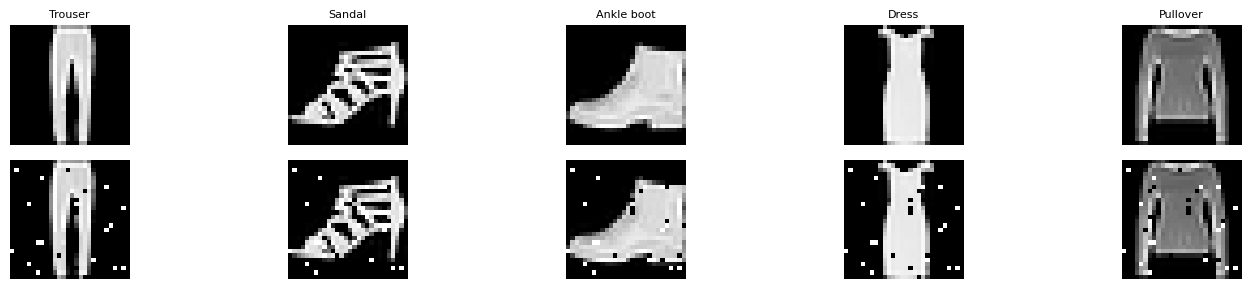

In [5]:
original_images, noisy_images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 3))

for i in range(5):
    img = original_images[i].permute(1, 2, 0)
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(dataset.classes[labels[i]], fontsize=8)
    axes[0, i].axis("off")

    noisy_img = noisy_images[i].permute(1, 2, 0)
    axes[1, i].imshow(noisy_img, cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10, rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Noisy", fontsize=10, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

## Initialize all contestants
- variational autoencoder
- classic autoencoder
- β-variational autoencoder

In [6]:
classic = AutoEncoder(latent_space=10).to(device)
variational = VAEAutoencoder(latent_dim=10).to(device)
beta_variational = VAEAutoencoder(latent_dim=10).to(device)

In [14]:
models = [
    {
        "name": "Classic AE",
        "model": classic,
        "beta": 0.0,
        "train_loss": 0.0,
        "test_losses": [],
        "validation_losses": [],
        "ssim_scores": [],
        "psnr_scores": [],
        "original_images": [],
        "model_reconstructed_images": [],
        "train_method": train_loop_ae,
        "test_method": ae_test_model_on,
        "is_vae": False,
    },
    {
        "name": "VAE",
        "model": variational,
        "beta": 0.0,
        "train_loss": 0.0,
        "test_losses": [],
        "validation_losses": [],
        "ssim_scores": [],
        "psnr_scores": [],
        "original_images": [],
        "model_reconstructed_images": [],
        "train_method": train_loop_vae,
        "test_method": vae_test_model_on,
        "is_vae": True,
    },
    {
        "name": "β-VAE (β=3.0)",
        "model": beta_variational,
        "beta": 0.03,
        "train_loss": 0.0,
        "test_losses": [],
        "validation_losses": [],
        "ssim_scores": [],
        "psnr_scores": [],
        "original_images": [],
        "model_reconstructed_images": [],
        "train_method": train_loop_vae,
        "test_method": vae_test_model_on,
        "is_vae": True,
    },
]

In [ ]:
for entry in models:
    print(f"\n{'='*60}")
    print(f"Training: {entry['name']}")
    print(f"{'='*60}")

    optimizer = torch.optim.Adam(
        lr=hyper_params.learning_rate,
        params=entry["model"].parameters(),
        weight_decay=1e-8,
    )
    criterion = nn.MSELoss()
    criterion.to(device)

    train_loss = entry["train_loss"]
    test_losses = entry["test_losses"]
    validation_losses = entry["validation_losses"]
    ssim_scores = entry["ssim_scores"]
    psnr_scores = entry["psnr_scores"]
    original_images = entry["original_images"]
    model_reconstructed_images = entry["model_reconstructed_images"]

    for i in range(hyper_params.epochs):
        curr_loss, original_image, reconstructed_image = entry["train_method"](
            entry["model"], train_loader, optimizer, criterion, device, beta=entry["beta"]
        )

        # Calculate SSIM and PSNR
        orig_np = original_image.detach().cpu().numpy().squeeze()
        recon_np = reconstructed_image.detach().cpu().numpy().squeeze()
        ssim_score, psnr_score = calculate_metrics_batch(
            orig_np.reshape(-1, 28, 28),
            recon_np.reshape(-1, 28, 28)
        )

        ssim_scores.append(ssim_score)
        psnr_scores.append(psnr_score)

        print(f"Epoch {i + 1}/{hyper_params.epochs}: loss = {curr_loss:.4f}, SSIM = {ssim_score:.4f}, PSNR = {psnr_score:.2f} dB")
        train_loss += curr_loss
        test_loss = entry["test_method"](entry["model"], test_loader, criterion, device)
        test_losses.append(test_loss)
        validation_loss = entry["test_method"](entry["model"], val_loader, criterion, device)
        validation_losses.append(validation_loss)

        original_images.append(orig_np)
        model_reconstructed_images.append(recon_np)

    print(f"\n{entry['name']} - Final Results:")
    print(f"  Average Training Loss: {(train_loss / hyper_params.epochs):.4f}")
    print(f"  Average Validation Loss: {sum(validation_losses) / hyper_params.epochs:.4f}")
    print(f"  Average Test Loss: {sum(test_losses) / hyper_params.epochs:.4f}")
    print(f"  Average SSIM: {np.mean(ssim_scores):.4f}")
    print(f"  Average PSNR: {np.mean(psnr_scores):.2f} dB")


Training: Classic AE
Epoch 1/10: loss = 0.0173, SSIM = 0.6508, PSNR = 17.88 dB


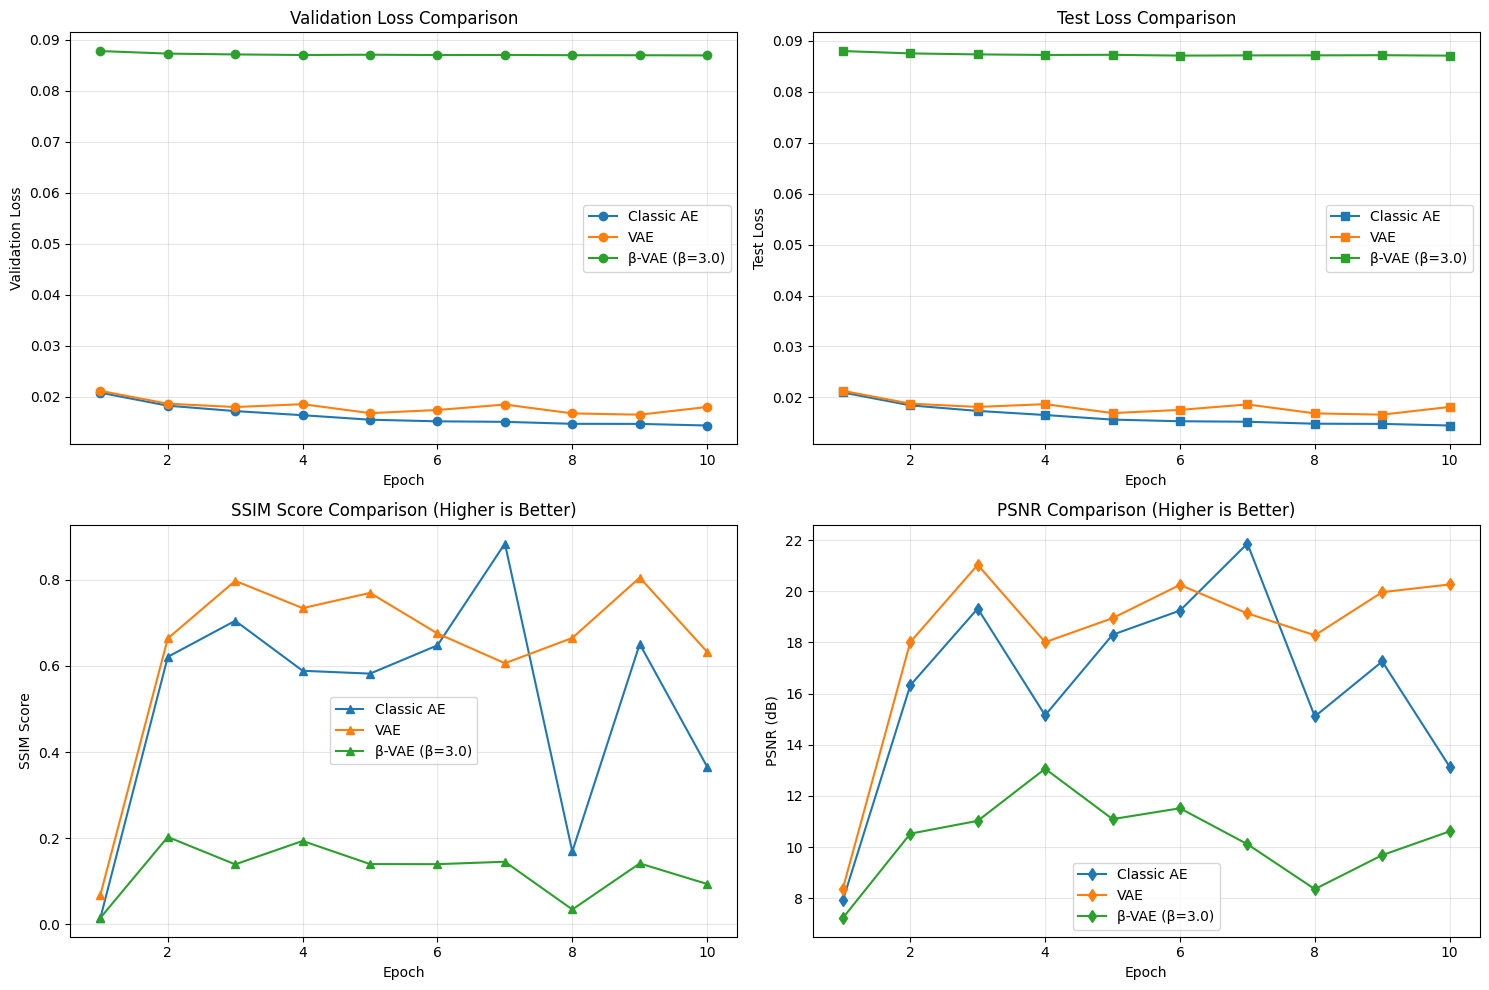

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, hyper_params.epochs + 1)

# Training Loss
for entry in models:
    axes[0, 0].plot(epochs_range, entry['validation_losses'], label=entry['name'], marker='o')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Validation Loss')
axes[0, 0].set_title('Validation Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Test Loss
for entry in models:
    axes[0, 1].plot(epochs_range, entry['test_losses'], label=entry['name'], marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Test Loss')
axes[0, 1].set_title('Test Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# SSIM Scores
for entry in models:
    axes[1, 0].plot(epochs_range, entry['ssim_scores'], label=entry['name'], marker='^')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('SSIM Score')
axes[1, 0].set_title('SSIM Score Comparison (Higher is Better)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# PSNR Scores
for entry in models:
    axes[1, 1].plot(epochs_range, entry['psnr_scores'], label=entry['name'], marker='d')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('PSNR (dB)')
axes[1, 1].set_title('PSNR Comparison (Higher is Better)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"{'Model':<20} {'Avg Val Loss':<15} {'Avg Test Loss':<15} {'Avg SSIM':<12} {'Avg PSNR':<12}")
print("-"*80)
for entry in models:
    print(f"{entry['name']:<20} "
          f"{np.mean(entry['validation_losses']):<15.4f} "
          f"{np.mean(entry['test_losses']):<15.4f} "
          f"{np.mean(entry['ssim_scores']):<12.4f} "
          f"{np.mean(entry['psnr_scores']):<12.2f}")
print("="*80)


SUMMARY TABLE
Model                Avg Val Loss    Avg Test Loss   Avg SSIM     Avg PSNR    
--------------------------------------------------------------------------------
Classic AE           0.0162          0.0164          0.5228       16.36       
VAE                  0.0180          0.0182          0.6416       18.23       
β-VAE (β=3.0)        0.0871          0.0872          0.1246       10.32       


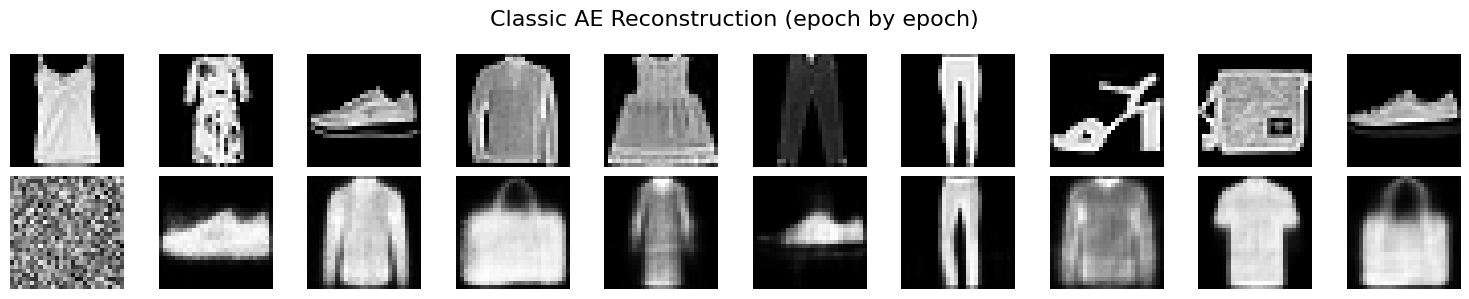

In [11]:
fig, axes = plt.subplots(2, hyper_params.epochs, figsize=(15, 3))
autoencoder = models[0]

for i in range(hyper_params.epochs):
    img = original_images[i]
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].axis("off")

    noisy_img = autoencoder["model_reconstructed_images"][i].reshape(28, 28)
    axes[1, i].imshow(noisy_img, cmap="gray")
    axes[1, i].axis("off")

plt.suptitle(f"{autoencoder["name"]} Reconstruction (epoch by epoch)", fontsize=16)
plt.tight_layout()
plt.show()

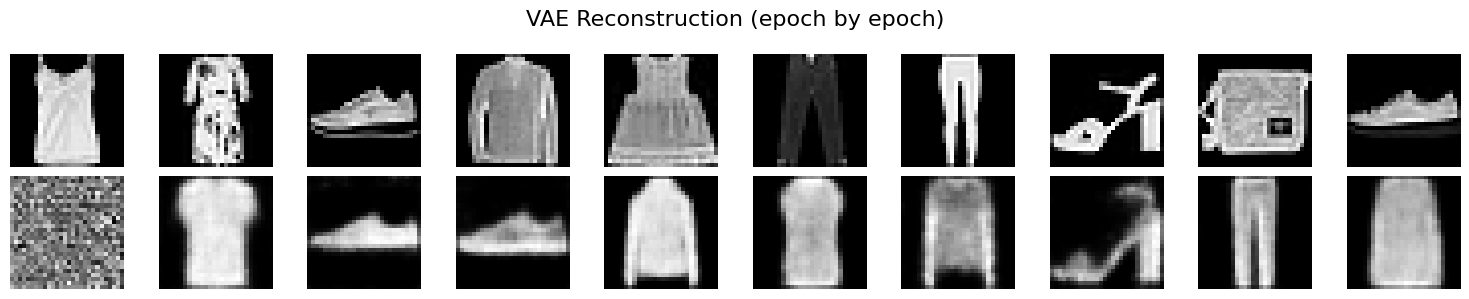

In [12]:
fig, axes = plt.subplots(2, hyper_params.epochs, figsize=(15, 3))
autoencoder = models[1]

for i in range(hyper_params.epochs):
    img = original_images[i]
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].axis("off")

    noisy_img = autoencoder["model_reconstructed_images"][i].reshape(28, 28)
    axes[1, i].imshow(noisy_img, cmap="gray")
    axes[1, i].axis("off")

plt.suptitle(f"{autoencoder["name"]} Reconstruction (epoch by epoch)", fontsize=16)
plt.tight_layout()
plt.show()

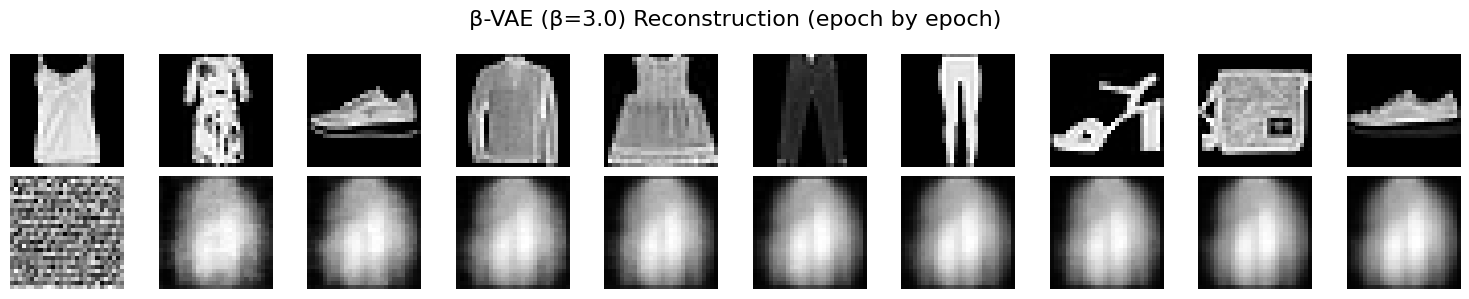

In [13]:
fig, axes = plt.subplots(2, hyper_params.epochs, figsize=(15, 3))
autoencoder = models[2]

for i in range(hyper_params.epochs):
    img = original_images[i]
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].axis("off")

    noisy_img = autoencoder["model_reconstructed_images"][i].reshape(28, 28)
    axes[1, i].imshow(noisy_img, cmap="gray")
    axes[1, i].axis("off")

plt.suptitle(f"{autoencoder["name"]} Reconstruction (epoch by epoch)", fontsize=16)
plt.tight_layout()
plt.show()